# Intensywność emisyjna produkcji energii elektrycznej na świecie

**Projekt eksploracyjnej analizy danych (EDA)** przygotowany na podstawie pliku `owid-energy-data.csv`.

**Główna zmienna zależna:** `carbon_intensity_elec` — intensywność emisji CO₂ produkcji energii elektrycznej, mierzona w gramach CO₂ na kWh.

**Zakres głównej analizy:** przekrój krajów/terytoriów w **2022 r.**  
Wybrano 2022 r., ponieważ w tym pliku jest to najnowszy rok zapewniający bardzo wysokie pokrycie zmiennej zależnej i jednocześnie dostępność danych PKB. Dla porównania: 2024 ma tylko 86 niepustych obserwacji intensywności emisji i brak PKB, 2023 ma 172 obserwacje intensywności emisji i brak PKB, a 2022 ma 212 obserwacji intensywności emisji oraz 165 obserwacji PKB.

> **Uwaga metodologiczna:** analiza ma charakter eksploracyjny i przekrojowy. Zależności statystyczne nie są interpretowane jako związki przyczynowe.


## 1. Wprowadzenie

### Zbiór danych
Zbiór integruje wskaźniki dotyczące zużycia energii, miksu energetycznego, produkcji energii elektrycznej i innych zmiennych energetycznych.

W pliku jedna obserwacja odpowiada kombinacji **lokalizacja × rok**. Do głównej analizy przekrojowej usuwamy agregaty OWID (np. regiony i świat) i pozostawiamy jednostki z kodami ISO.

### Pytania badawcze
1. **Czy większy udział OZE w produkcji energii elektrycznej wiąże się z niższą intensywnością emisyjną?**
2. **Jak silnie udział paliw kopalnych wiąże się z intensywnością emisyjną?**
3. **Czy udział energetyki jądrowej, hydro, wiatru i fotowoltaiki różnicuje intensywność emisji?**
4. **Czy zamożność i skala zużycia energii na mieszkańca są wyraźnie związane z intensywnością emisyjną?**

Analizowane są więc relacje wielu zmiennych z jedną główną zmienną zależną, co odpowiada charakterowi analizy przekrojowej i eksploracyjnej.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

DATA_PATH = Path("owid-energy-data.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/energy_eda_project/owid-energy-data.csv")

df = pd.read_csv(DATA_PATH)
print("Wymiary pełnego zbioru:", df.shape)
print("Zakres lat:", int(df["year"].min()), "-", int(df["year"].max()))
print("Liczba unikalnych lokalizacji:", df["country"].nunique())
df.head()

Wymiary pełnego zbioru: (23195, 130)
Zakres lat: 1900 - 2024
Liczba unikalnych lokalizacji: 314


,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


**Interpretacja:** Pełny plik ma 23 195 wierszy i 130 kolumn obejmuje lata 1900–2024 i zawiera 314 unikalnych nazw lokalizacji. Ze względu na bardzo szeroki zakres czasowy i nierówną dostępność danych między latami dalsza analiza koncentruje się na porównywalnym przekroju 2022.

## 2. Czyszczenie i porządkowanie danych
- wybór roku i jednostek analizy,
- diagnostykę braków danych,
- sprawdzenie duplikatów,
- kontrolę podstawowych zakresów wartości,
- identyfikację obserwacji odstających metodą IQR,
- utworzenie zmiennej `gdp_per_capita`,
- decyzję dotyczącą imputacji.

**Strategia braków:** nie imputujemy sztucznie zmiennej zależnej ani udziałów źródeł energii. W analizach wykorzystujemy obserwacje kompletne dla konkretnej pary/grupy zmiennych (pairwise complete cases). Dzięki temu nie tworzymy nieistniejących wartości energetycznych. Brak PKB na mieszkańca traktujemy jako brak strukturalny i jawnie raportujemy liczebność próby.

In [16]:
# Porównanie pokrycia danych w najnowszych latach
rows = []
for y in [2022, 2023, 2024]:
    s = df[
        (df["year"] == y)
        & df["iso_code"].notna()
        & (~df["iso_code"].astype(str).str.startswith("OWID"))
    ].copy()
    rows.append({
        "rok": y,
        "liczba_jednostek": len(s),
        "carbon_intensity_elec_n": s["carbon_intensity_elec"].notna().sum(),
        "gdp_n": s["gdp"].notna().sum(),
        "renewables_share_elec_n": s["renewables_share_elec"].notna().sum()
    })

coverage = pd.DataFrame(rows).set_index("rok")
coverage


,liczba_jednostek,carbon_intensity_elec_n,gdp_n,renewables_share_elec_n
rok,,,,
2022,220,212,165,212
2023,220,172,0,174
2024,123,86,0,100


In [17]:
selected_cols = [
    "country", "year", "iso_code", "population", "gdp",
    "carbon_intensity_elec", "renewables_share_elec", "fossil_share_elec",
    "nuclear_share_elec", "hydro_share_elec", "wind_share_elec",
    "solar_share_elec", "electricity_demand_per_capita", "energy_per_capita"
]

data = df[
    (df["year"] == 2022)
    & df["iso_code"].notna()
    & (~df["iso_code"].astype(str).str.startswith("OWID"))
][selected_cols].copy()

data["gdp_per_capita"] = data["gdp"] / data["population"]

print("Liczba jednostek po filtrze:", len(data))
print("Duplikaty country/iso_code/year:", data.duplicated(["iso_code", "year"]).sum())
data.head()


Liczba jednostek po filtrze: 220
Duplikaty country/iso_code/year: 0


,country,year,iso_code,population,gdp,carbon_intensity_elec,renewables_share_elec,fossil_share_elec,nuclear_share_elec,hydro_share_elec,wind_share_elec,solar_share_elec,electricity_demand_per_capita,energy_per_capita,gdp_per_capita
147,Afghanistan,2022,AFG,40578801.0,5.330347e+10,125.000,86.458,13.542,0.0,77.083,0.000,9.375,168.561,1111.574,1313.579278
642,Albania,2022,ALB,2827562.0,3.617101e+10,24.390,100.000,0.000,0.0,97.704,0.000,2.296,2790.390,9147.373,12792.294546
766,Algeria,2022,DZA,45477339.0,5.958200e+11,633.650,0.940,99.060,0.0,0.022,0.011,0.907,1954.820,16145.355,13101.470596
811,American Samoa,2022,ASM,48322.0,NaN,611.111,5.556,94.444,0.0,0.000,0.000,5.556,3725.011,32868.645,NaN
935,Angola,2022,AGO,35634984.0,1.583462e+11,172.155,75.563,24.437,0.0,73.021,0.000,2.253,485.759,2713.828,4443.561647


In [18]:
analysis_cols = [
    "carbon_intensity_elec", "renewables_share_elec", "fossil_share_elec",
    "nuclear_share_elec", "hydro_share_elec", "wind_share_elec",
    "solar_share_elec", "electricity_demand_per_capita", "energy_per_capita",
    "gdp_per_capita"
]

missing = pd.DataFrame({
    "braki_n": data[analysis_cols].isna().sum(),
    "braki_pct": (data[analysis_cols].isna().mean() * 100).round(1)
}).sort_values("braki_pct", ascending=False)

missing


,braki_n,braki_pct
gdp_per_capita,55,25.0
nuclear_share_elec,12,5.5
wind_share_elec,9,4.1
carbon_intensity_elec,8,3.6
renewables_share_elec,8,3.6
fossil_share_elec,8,3.6
hydro_share_elec,8,3.6
solar_share_elec,8,3.6
electricity_demand_per_capita,7,3.2
energy_per_capita,4,1.8


**Komentarz do braków.** W większości kluczowych zmiennych udział braków jest niewielki. Największy brak dotyczy `gdp_per_capita`: około **25.0%** jednostek w przekroju 2022. Zamiast imputować PKB, analiza tej zmiennej będzie wykonana na mniejszej, jawnie podanej próbie.


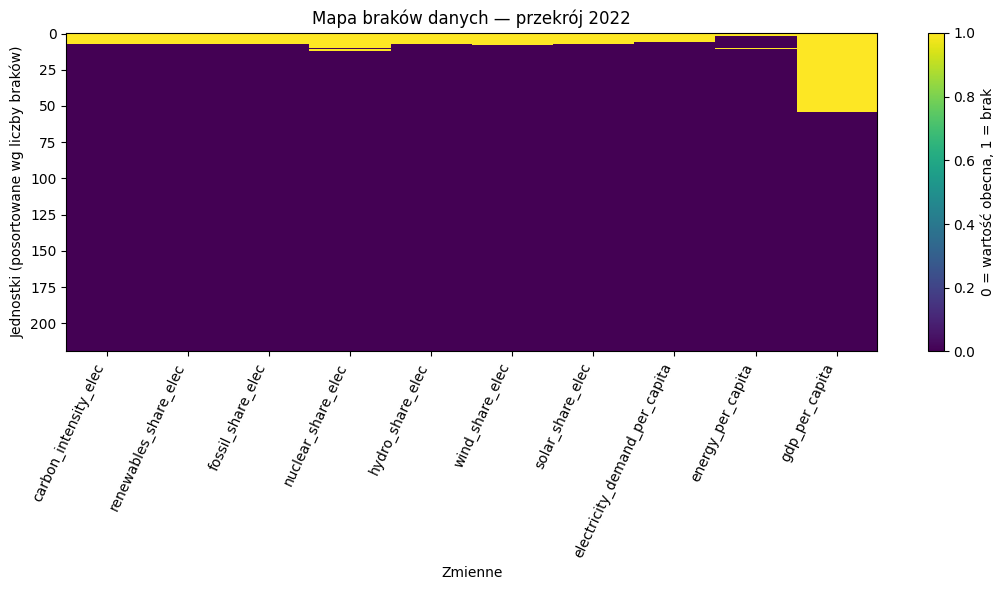

In [19]:
# Shadowmap / mapa braków danych
miss_matrix = data[analysis_cols].isna().astype(int)
order = miss_matrix.sum(axis=1).sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 6))
img = ax.imshow(miss_matrix.loc[order].values, aspect="auto", interpolation="nearest")
ax.set_title("Mapa braków danych — przekrój 2022")
ax.set_xlabel("Zmienne")
ax.set_ylabel("Jednostki (posortowane wg liczby braków)")
ax.set_xticks(range(len(analysis_cols)))
ax.set_xticklabels(analysis_cols, rotation=65, ha="right")
fig.colorbar(img, ax=ax, label="0 = wartość obecna, 1 = brak")
plt.tight_layout()
plt.show()


In [20]:
# Kontrola zakresów udziałów procentowych
share_cols = [
    "renewables_share_elec", "fossil_share_elec", "nuclear_share_elec",
    "hydro_share_elec", "wind_share_elec", "solar_share_elec"
]
range_check = pd.DataFrame({
    "min": data[share_cols].min(),
    "max": data[share_cols].max(),
    "poza_0_100": [((data[c] < 0) | (data[c] > 100)).sum() for c in share_cols]
})
range_check


,min,max,poza_0_100
renewables_share_elec,0.0,100.000,0
fossil_share_elec,0.0,100.000,0
nuclear_share_elec,0.0,62.911,0
hydro_share_elec,0.0,100.000,0
wind_share_elec,0.0,54.387,0
solar_share_elec,0.0,50.000,0


In [21]:
# Identyfikacja obserwacji odstających metodą IQR
def iqr_flags(frame, column):
    s = frame[column].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    flags = frame[(frame[column] < low) | (frame[column] > high)][["country", column]].copy()
    flags["dolna_granica"] = low
    flags["gorna_granica"] = high
    return flags.sort_values(column, ascending=False)

outlier_tables = {}
for col in ["carbon_intensity_elec", "electricity_demand_per_capita", "energy_per_capita", "gdp_per_capita"]:
    outlier_tables[col] = iqr_flags(data, col)
    print(f"\n{col}: {len(outlier_tables[col])} obserwacji odstających wg IQR")
    display(outlier_tables[col].head(15))



carbon_intensity_elec: 1 obserwacji odstających wg IQR


,country,carbon_intensity_elec,dolna_granica,gorna_granica
21015,Turkmenistan,1306.135,-347.32375,1193.01025



electricity_demand_per_capita: 10 obserwacji odstających wg IQR


,country,electricity_demand_per_capita,dolna_granica,gorna_granica
9491,Iceland,52245.203,-6447.1455,12774.8825
15039,Norway,24355.143,-6447.1455,12774.8825
2093,Bahrain,23287.996,-6447.1455,12774.8825
17773,Qatar,18728.268,-6447.1455,12774.8825
10858,Kuwait,18583.857,-6447.1455,12774.8825
3906,Canada,15657.421,-6447.1455,12774.8825
7622,Finland,15206.705,-6447.1455,12774.8825
21568,United Arab Emirates,14957.968,-6447.1455,12774.8825
2684,Bhutan,14855.264,-6447.1455,12774.8825
19855,Sweden,13333.284,-6447.1455,12774.8825



energy_per_capita: 14 obserwacji odstających wg IQR


,country,energy_per_capita,dolna_granica,gorna_granica
17773,Qatar,195339.516,-41594.11525,77560.53675
9491,Iceland,167551.891,-41594.11525,77560.53675
2093,Bahrain,161788.438,-41594.11525,77560.53675
18730,Singapore,158523.266,-41594.11525,77560.53675
21568,United Arab Emirates,132097.562,-41594.11525,77560.53675
3259,Brunei,117683.320,-41594.11525,77560.53675
20725,Trinidad and Tobago,115689.680,-41594.11525,77560.53675
21937,United States Virgin Islands,107303.492,-41594.11525,77560.53675
3906,Canada,102122.555,-41594.11525,77560.53675
10858,Kuwait,102112.367,-41594.11525,77560.53675



gdp_per_capita: 5 obserwacji odstających wg IQR


,country,gdp_per_capita,dolna_granica,gorna_granica
17773,Qatar,131992.667806,-30099.694718,62015.655588
15039,Norway,88391.108215,-30099.694718,62015.655588
18730,Singapore,81737.128856,-30099.694718,62015.655588
21568,United Arab Emirates,76127.612393,-30099.694718,62015.655588
19980,Switzerland,63623.385923,-30099.694718,62015.655588


**Decyzja dotycząca obserwacji odstających.** Wartości odstające nie są automatycznie błędami. W danych energetycznych wysokie zużycie energii per capita lub bardzo wysoka intensywność emisji mogą mieć realne uzasadnienie strukturalne. Dlatego nie usuwamy ich mechanicznie; zamiast tego stosujemy także korelację rang Spearmana, mniej wrażliwą na wartości skrajne niż klasyczna korelacja Pearsona.

**Naprawa danych:** usunięto agregaty OWID z głównego przekroju, sprawdzono duplikaty i zakresy udziałów procentowych, utworzono PKB per capita oraz zastosowano kontrolę braków i wartości odstających. Dane źródłowe nie są nadpisywane.


## 3. Wizualizacje

Poniżej przedstawiono 5 wizualizacji odpowiadających pytaniom badawczym.

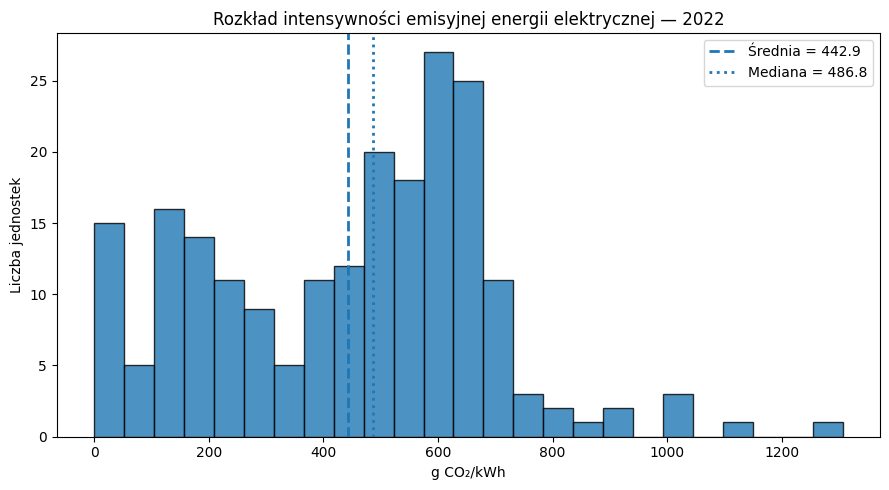

In [25]:
# 1. Rozkład głównej zmiennej zależnej
s = data["carbon_intensity_elec"].dropna()
mean_ci = s.mean()
median_ci = s.median()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(s, bins=25, edgecolor="black", alpha=0.8)
ax.axvline(mean_ci, linestyle="--", linewidth=2, label=f"Średnia = {mean_ci:.1f}")
ax.axvline(median_ci, linestyle=":", linewidth=2, label=f"Mediana = {median_ci:.1f}")
ax.set_title("Rozkład intensywności emisyjnej energii elektrycznej — 2022")
ax.set_xlabel("g CO₂/kWh")
ax.set_ylabel("Liczba jednostek")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretacja 1.** Rozkład intensywności emisyjnej jest szeroki: kraje różnią się bardzo mocno strukturą wytwarzania energii. Widoczny jest długi górny ogon, dlatego oprócz średniej warto analizować medianę i statystyki odporne.


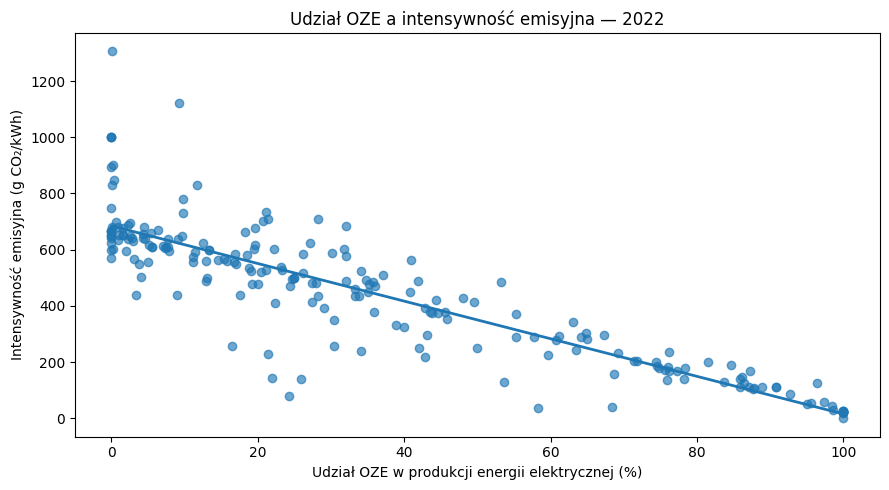

In [26]:
# 2. OZE a intensywność emisyjna
plot_df = data[["renewables_share_elec", "carbon_intensity_elec"]].dropna()
x = plot_df["renewables_share_elec"].to_numpy()
y = plot_df["carbon_intensity_elec"].to_numpy()
coef = np.polyfit(x, y, 1)
xx = np.linspace(x.min(), x.max(), 200)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x, y, alpha=0.65)
ax.plot(xx, np.polyval(coef, xx), linewidth=2)
ax.set_title("Udział OZE a intensywność emisyjna — 2022")
ax.set_xlabel("Udział OZE w produkcji energii elektrycznej (%)")
ax.set_ylabel("Intensywność emisyjna (g CO₂/kWh)")
plt.tight_layout()
plt.show()


**Interpretacja 2.** Zależność jest wyraźnie ujemna: im większy udział OZE, tym zwykle niższa intensywność emisyjna. Korelacja Spearmana wynosi **ρ = -0.889** (n = 212), co wskazuje na bardzo silną monotoniczną zależność w tym przekroju.


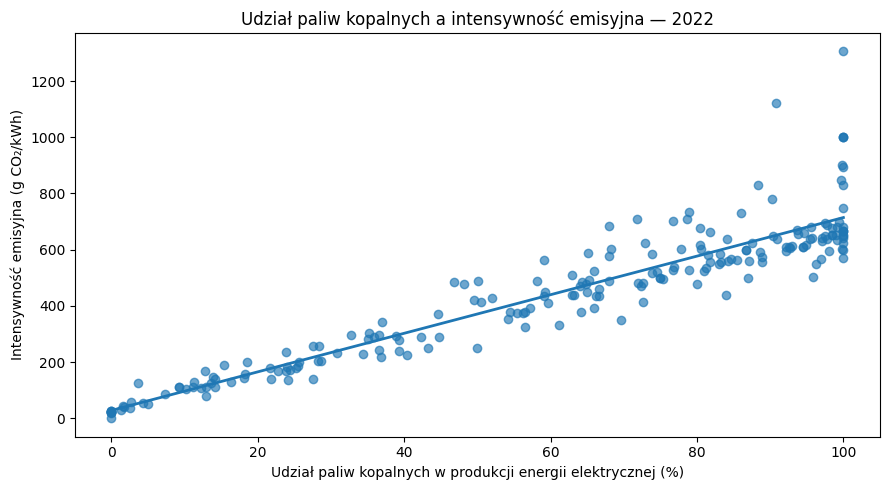

In [27]:
# 3. Paliwa kopalne a intensywność emisyjna
plot_df = data[["fossil_share_elec", "carbon_intensity_elec"]].dropna()
x = plot_df["fossil_share_elec"].to_numpy()
y = plot_df["carbon_intensity_elec"].to_numpy()
coef = np.polyfit(x, y, 1)
xx = np.linspace(x.min(), x.max(), 200)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x, y, alpha=0.65)
ax.plot(xx, np.polyval(coef, xx), linewidth=2)
ax.set_title("Udział paliw kopalnych a intensywność emisyjna — 2022")
ax.set_xlabel("Udział paliw kopalnych w produkcji energii elektrycznej (%)")
ax.set_ylabel("Intensywność emisyjna (g CO₂/kWh)")
plt.tight_layout()
plt.show()


**Interpretacja 3.** Udział paliw kopalnych wykazuje bardzo silną dodatnią relację z intensywnością emisyjną: **ρ = 0.933** (n = 212). Jest to najsilniejsza pojedyncza zależność w analizowanym zestawie zmiennych.


In [ ]:
# 4. Intensywność emisyjna w kwartylach udziału OZE
box_df = data[["renewables_share_elec", "carbon_intensity_elec"]].dropna().copy()
box_df["kwartyl_OZE"] = pd.qcut(
    box_df["renewables_share_elec"], q=4,
    labels=["Q1: najniższy", "Q2", "Q3", "Q4: najwyższy"]
)

groups = [
    box_df.loc[box_df["kwartyl_OZE"] == label, "carbon_intensity_elec"]
    for label in ["Q1: najniższy", "Q2", "Q3", "Q4: najwyższy"]
]

fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(groups, tick_labels=["Q1", "Q2", "Q3", "Q4"], showmeans=True)
ax.set_title("Intensywność emisyjna według kwartylu udziału OZE")
ax.set_xlabel("Kwartyl udziału OZE")
ax.set_ylabel("Intensywność emisyjna (g CO₂/kWh)")
plt.tight_layout()
plt.show()

box_df.groupby("kwartyl_OZE", observed=True)["carbon_intensity_elec"].agg(
    liczba="count", srednia="mean", mediana="median"
).round(1)
